## Load Dataset

Dataset utama adalah Weather AUS yang berisi **145.460 baris** dan **23 kolom**.

In [ ]:
import pandas as pd

df = pd.read_csv('/content/weatherAUS.csv')

print(f'Shape dataset: {df.shape}')
print(f'Kolom: {df.columns.tolist()}')
display(df)

Shape dataset: (145460, 23)
Kolom: ['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow']


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No


## EDA

Memeriksa distribusi target, nilai kosong, dan statistik deskriptif dasar.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [ ]:
missing = pd.DataFrame({
    "tipe data": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Persen": (df.isnull().sum() / len(df) * 100).round(2)
})

print(missing)

              tipe data  Missing Values  Persen
Date             object               0    0.00
Location         object               0    0.00
MinTemp         float64            1485    1.02
MaxTemp         float64            1261    0.87
Rainfall        float64            3261    2.24
Evaporation     float64           62790   43.17
Sunshine        float64           69835   48.01
WindGustDir      object           10326    7.10
WindGustSpeed   float64           10263    7.06
WindDir9am       object           10566    7.26
WindDir3pm       object            4228    2.91
WindSpeed9am    float64            1767    1.21
WindSpeed3pm    float64            3062    2.11
Humidity9am     float64            2654    1.82
Humidity3pm     float64            4507    3.10
Pressure9am     float64           15065   10.36
Pressure3pm     float64           15028   10.33
Cloud9am        float64           55888   38.42
Cloud3pm        float64           59358   40.81
Temp9am         float64            1767 

               Count  Percentage (%)
RainTomorrow                        
No            110316           75.84
Yes            31877           21.91
NaN             3267            2.25


/tmp/ipykernel_1636/244704460.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


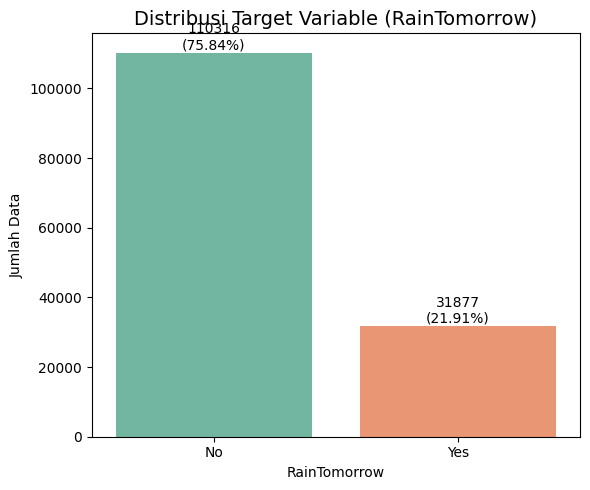

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

target_counts = df["RainTomorrow"].value_counts(dropna=False)
target_percent = (target_counts / len(df) * 100).round(2)

print(pd.DataFrame({
    "Count": target_counts,
    "Percentage (%)": target_percent
}))

plt.figure(figsize=(6, 5))
ax = sns.countplot(
    data=df,
    x="RainTomorrow",
    palette="Set2"
)

plt.title("Distribusi Target Variable (RainTomorrow)", fontsize=14)
plt.xlabel("RainTomorrow")
plt.ylabel("Jumlah Data")

for p in ax.patches:
    height = p.get_height()
    percentage = height / len(df) * 100
    ax.annotate(
        f'{int(height)}\n({percentage:.2f}%)',
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

## Handling Missing Values

Handling missing values <10%

In [ ]:
from sklearn.model_selection import train_test_split

df = df.dropna(subset=["RainTomorrow"])
X = df.drop("RainTomorrow", axis=1)
y = df["RainTomorrow"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (113754, 22)
X_test  : (28439, 22)
y_train : (113754,)
y_test  : (28439,)


In [ ]:
missing_train = pd.DataFrame({
    "Tipe Data": X_train.dtypes,
    "Missing Values": X_train.isnull().sum(),
    "Persen (%)": (X_train.isnull().sum() / len(X_train) * 100).round(2)
})

print(missing_train)

              Tipe Data  Missing Values  Persen (%)
Date             object               0        0.00
Location         object               0        0.00
MinTemp         float64             513        0.45
MaxTemp         float64             258        0.23
Rainfall        float64            1131        0.99
Evaporation     float64           48695       42.81
Sunshine        float64           54344       47.77
WindGustDir      object            7485        6.58
WindGustSpeed   float64            7440        6.54
WindDir9am       object            8055        7.08
WindDir3pm       object            3066        2.70
WindSpeed9am    float64            1082        0.95
WindSpeed3pm    float64            2130        1.87
Humidity9am     float64            1418        1.25
Humidity3pm     float64            2897        2.55
Pressure9am     float64           11287        9.92
Pressure3pm     float64           11262        9.90
Cloud9am        float64           42877       37.69
Cloud3pm    

Kolom dengan **missing values <10%** dilakukan imputasi dengan mempertimbangkan karakteristik temporal dan spasial data cuaca. Interpolasi linear berdasarkan lokasi digunakan sebagai metode utama. Apabila interpolasi tidak dapat dilakukan, nilai kosong diisi menggunakan mean atau median berdasarkan karakteristik distribusi data melalui analisis skewness untuk mempertahankan pola statistik masing-masing fitur.

In [ ]:
import pandas as pd
import numpy as np

X_train["Date"] = pd.to_datetime(X_train["Date"])
X_test["Date"] = pd.to_datetime(X_test["Date"])
sort_index = X_train.sort_values(["Location", "Date"]).index
X_train = X_train.loc[sort_index].reset_index(drop=True)
y_train = y_train.loc[sort_index].reset_index(drop=True)

numeric_cols = [
    "MinTemp",
    "MaxTemp",
    "Rainfall",
    "WindGustSpeed",
    "WindSpeed9am",
    "WindSpeed3pm",
    "Humidity9am",
    "Humidity3pm",
    "Pressure9am",
    "Pressure3pm",
    "Temp9am",
    "Temp3pm"
]

skew_info = {}

print("Skewness Training Data")
print("="*50)

for col in numeric_cols:

    skew = X_train[col].dropna().skew()

    skew_info[col] = skew

    print(
        f"{col:<20}: {skew:.3f}"
    )

location_mean = (
    X_train
    .groupby("Location")[numeric_cols]
    .mean()
)

location_median = (
    X_train
    .groupby("Location")[numeric_cols]
    .median()
)

global_mean = (
    X_train[numeric_cols]
    .mean()
)

global_median = (
    X_train[numeric_cols]
    .median()
)

def interpolate_train(df, cols):

    for col in cols:
        df[col] = df.groupby(
            "Location"
        )[col].transform(
            lambda x: x.interpolate(
                method="linear",
                limit_direction="both"
            )
        )

        if abs(skew_info[col]) <= 0.5:

            df[col] = df[col].fillna(
                df.groupby("Location")[col]
                .transform("mean")
            )

        else:

            df[col] = df[col].fillna(
                df.groupby("Location")[col]
                .transform("median")
            )

        if abs(skew_info[col]) <= 0.5:

            df[col] = df[col].fillna(
                global_mean[col]
            )

        else:

            df[col] = df[col].fillna(
                global_median[col]
            )

    return df

X_train = interpolate_train(
    X_train,
    numeric_cols
)

for col in numeric_cols:
    if abs(skew_info[col]) <= 0.5:
        X_test[col] = X_test[col].fillna(
            X_test["Location"]
            .map(location_mean[col])
        )

        X_test[col] = X_test[col].fillna(
            global_mean[col]
        )


    else:

        X_test[col] = X_test[col].fillna(
            X_test["Location"]
            .map(location_median[col])
        )

        X_test[col] = X_test[col].fillna(
            global_median[col]
        )

categorical_cols = [
    "WindGustDir",
    "WindDir9am",
    "WindDir3pm",
    "RainToday"
]

location_mode = {}

for col in categorical_cols:

    location_mode[col] = (
        X_train
        .groupby("Location")[col]
        .agg(
            lambda x: x.mode()[0]
            if not x.mode().empty
            else np.nan
        )
    )

global_mode = {}

for col in categorical_cols:

    global_mode[col] = (
        X_train[col]
        .mode()[0]
    )

for col in categorical_cols:

    X_train[col] = X_train[col].fillna(
        X_train["Location"]
        .map(location_mode[col])
    )

    X_train[col] = X_train[col].fillna(
        global_mode[col]
    )

for col in categorical_cols:

    X_test[col] = X_test[col].fillna(
        X_test["Location"]
        .map(location_mode[col])
    )

    X_test[col] = X_test[col].fillna(
        global_mode[col]
    )

print("\nMissing X_train")
missing_train = pd.DataFrame({
    "Missing Values": X_train.isnull().sum(),
    "Percentage (%)":
        (X_train.isnull().sum()/len(X_train)*100).round(2)
})

display(
    missing_train[
        missing_train["Missing Values"] > 0
    ]
)

print("\nMissing X_test")
missing_test = pd.DataFrame({
    "Missing Values": X_test.isnull().sum(),
    "Percentage (%)":
        (X_test.isnull().sum()/len(X_test)*100).round(2)
})

display(
    missing_test[
        missing_test["Missing Values"] > 0
    ]
)

Skewness Training Data
MinTemp             : 0.024
MaxTemp             : 0.222
Rainfall            : 10.090
WindGustSpeed       : 0.876
WindSpeed9am        : 0.765
WindSpeed3pm        : 0.625
Humidity9am         : -0.487
Humidity3pm         : 0.034
Pressure9am         : -0.098
Pressure3pm         : -0.049
Temp9am             : 0.092
Temp3pm             : 0.237

Missing X_train


,Missing Values,Percentage (%)
Evaporation,48695,42.81
Sunshine,54344,47.77
Cloud9am,42877,37.69
Cloud3pm,45669,40.15



Missing X_test


,Missing Values,Percentage (%)
Evaporation,12148,42.72
Sunshine,13472,47.37
Cloud9am,10780,37.91
Cloud3pm,11425,40.17


Handling missing values >35%

In [ ]:
import pandas as pd
import numpy as np

high_missing_cols = [
    "Evaporation",
    "Sunshine",
    "Cloud9am",
    "Cloud3pm"
]

print("ANALISIS MISSING VALUE TERHADAP TARGET")
print("="*80)

for col in high_missing_cols:

    print("\n", "="*70)
    print(f"Kolom : {col}")

    missing_target = (
        X_train[col]
        .isnull()
        .groupby(y_train)
        .mean()
        *100
    )

    display(
        pd.DataFrame({
            "Missing Percentage (%)": missing_target.round(2)
        })
    )

for col in high_missing_cols:
    X_train[col + "_missing"] = (
        X_train[col]
        .isnull()
        .astype(int)
    )
    X_test[col + "_missing"] = (
        X_test[col]
        .isnull()
        .astype(int)
    )

print("\nANALISIS MISSING INDICATOR TERHADAP TARGET")
print("="*80)


for col in high_missing_cols:

    indicator = col + "_missing"

    print("\n", "="*70)
    print(f"Indicator : {indicator}")

    display(
        pd.crosstab(
            X_train[indicator],
            y_train,
            normalize="index"
        )
        .round(3)
        *
        100
    )

print("\nDISTRIBUSI NILAI YANG TERSEDIA")
print("="*80)

for col in high_missing_cols:

    print("\n", "="*70)
    print(f"Kolom : {col}")

    display(
        X_train
        .assign(
            RainTomorrow=y_train.values
        )
        .groupby("RainTomorrow")[col]
        .describe()
        .round(3)
    )

ANALISIS MISSING VALUE TERHADAP TARGET

Kolom : Evaporation


,Missing Percentage (%)
RainTomorrow,
No,42.48
Yes,43.95



Kolom : Sunshine


,Missing Percentage (%)
RainTomorrow,
No,47.90
Yes,47.33



Kolom : Cloud9am


...

,count,mean,std,min,25%,50%,75%,max
RainTomorrow,,,,,,,,
No,45978.0,8.543,3.385,0.0,6.6,9.4,11.0,14.3
Yes,13432.0,4.472,3.359,0.0,1.4,4.3,7.1,13.9



Kolom : Cloud9am


,count,mean,std,min,25%,50%,75%,max
RainTomorrow,,,,,,,,
No,54376.0,3.930,2.879,0.0,1.0,4.0,7.0,9.0
Yes,16501.0,6.097,2.215,0.0,5.0,7.0,8.0,8.0



Kolom : Cloud3pm


,count,mean,std,min,25%,50%,75%,max
RainTomorrow,,,,,,,,
No,51843.0,3.920,2.670,0.0,1.0,4.0,7.0,9.0
Yes,16242.0,6.361,1.945,0.0,6.0,7.0,8.0,8.0


4 fitur dengan proporsi missing value tinggi, yaitu **Evaporation, Sunshine, Cloud9am, dan Cloud3pm,** dianalisis lebih lanjut menggunakan pendekatan missing pattern terhadap target, missing indicator, serta distribusi statistik berdasarkan kelas target. Hasil analisis menunjukkan bahwa persentase missing antar kelas memiliki perbedaan yang sangat kecil, sedangkan distribusi nilai fitur antara kelas RainTomorrow = Yes dan No relatif identik. Oleh karena itu, fitur tersebut dianggap kurang memberikan informasi prediktif dan dihapus untuk mengurangi noise pada proses pemodelan sehingga **perlu di drop**

In [ ]:
drop_cols = [
    "Evaporation",
    "Sunshine",
    "Cloud9am",
    "Cloud3pm"
]


X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

print("Missing Values X_train")
print("="*60)

missing_train = pd.DataFrame({
    "Tipe Data": X_train.dtypes,
    "Missing Values": X_train.isnull().sum(),
    "Percentage (%)": (
        X_train.isnull().sum() / len(X_train) * 100
    ).round(2)
})


display(
    missing_train[
        missing_train["Missing Values"] > 0
    ]
)

print("\nMissing Values X_test")
print("="*60)

missing_test = pd.DataFrame({
    "Tipe Data": X_test.dtypes,
    "Missing Values": X_test.isnull().sum(),
    "Percentage (%)": (
        X_test.isnull().sum() / len(X_test) * 100
    ).round(2)
})


display(
    missing_test[
        missing_test["Missing Values"] > 0
    ]
)

Missing Values X_train


,Tipe Data,Missing Values,Percentage (%)



Missing Values X_test


,Tipe Data,Missing Values,Percentage (%)


## Feature Selection

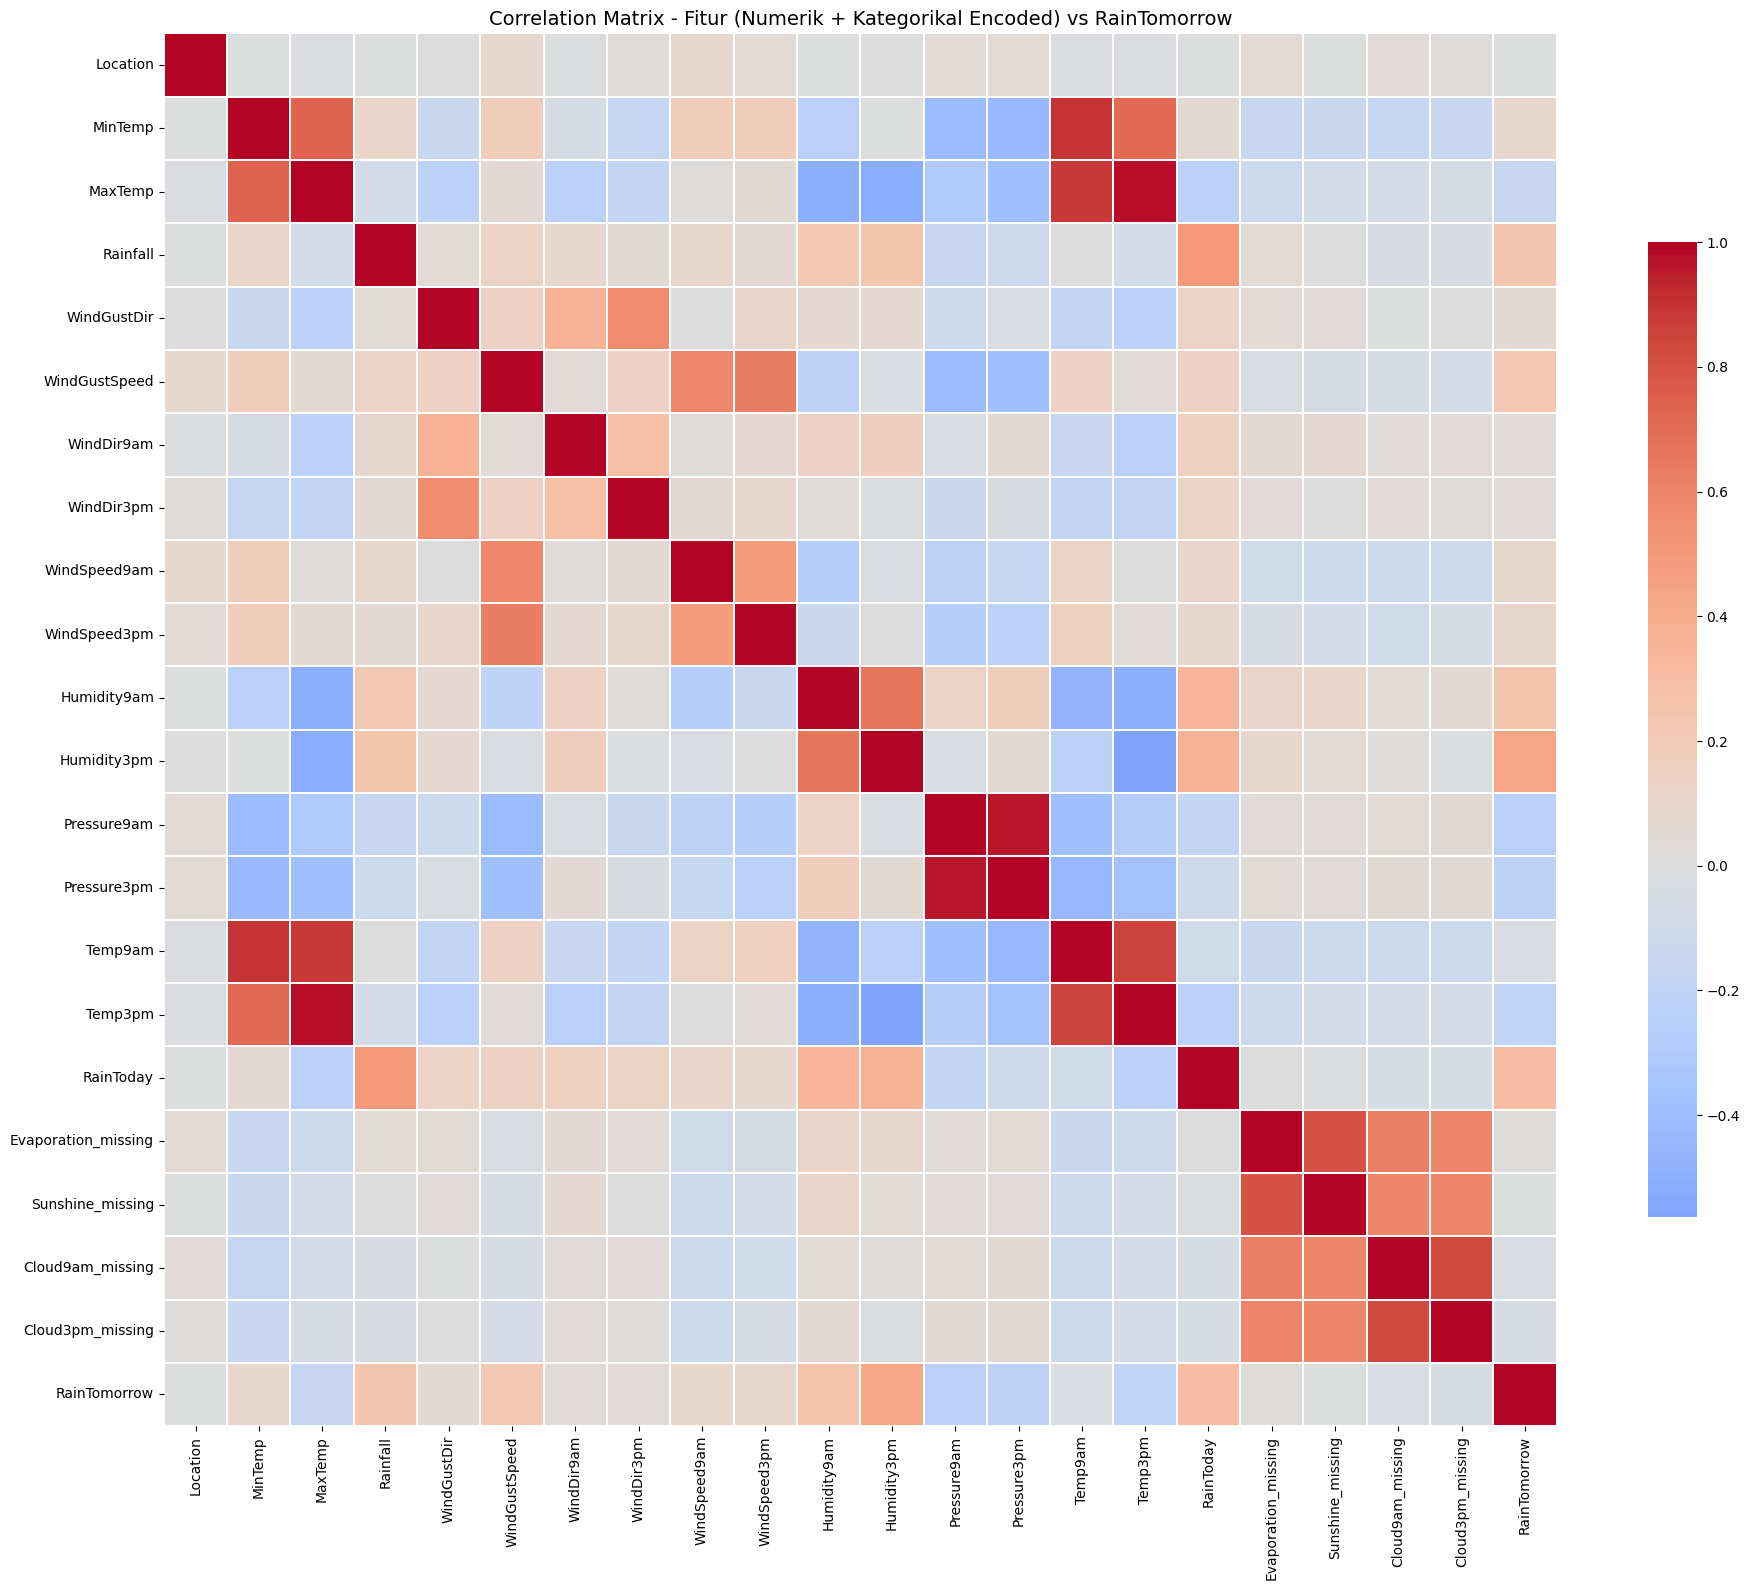

In [ ]:
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

df_corr = X_train.copy()
df_corr['RainTomorrow'] = y_train.values

if 'Date' in df_corr.columns:
    df_corr = df_corr.drop(columns=['Date'])

cat_cols = df_corr.select_dtypes(include='object').columns

for col in cat_cols:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col].astype(str))

corr_matrix = df_corr.corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False,
            square=True, linewidths=0.3, cbar_kws={"shrink": 0.7})
plt.title('Correlation Matrix - Fitur (Numerik + Kategorikal Encoded) vs RainTomorrow', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
threshold = 0.85
corr_matrix_features = corr_matrix.drop(index='RainTomorrow', columns='RainTomorrow')

corr_pairs = corr_matrix_features.abs().unstack()
corr_pairs = corr_pairs[corr_pairs < 1.0]
high_corr = corr_pairs[corr_pairs > threshold].sort_values(ascending=False)

high_corr = high_corr[~high_corr.index.duplicated()]
seen = set()
filtered = []
for (f1, f2), val in high_corr.items():
    pair = tuple(sorted([f1, f2]))
    if pair not in seen:
        seen.add(pair)
        filtered.append((f1, f2, val))

high_corr_df = pd.DataFrame(filtered, columns=['Fitur 1', 'Fitur 2', 'Korelasi'])
print(f"Jumlah pasangan fitur dengan |korelasi| > {threshold}: {len(high_corr_df)}")
display(high_corr_df)

Jumlah pasangan fitur dengan |korelasi| > 0.85: 5


,Fitur 1,Fitur 2,Korelasi
0,Temp3pm,MaxTemp,0.980309
1,Pressure3pm,Pressure9am,0.959261
2,Temp9am,MinTemp,0.902069
3,MaxTemp,Temp9am,0.887731
4,Temp9am,Temp3pm,0.858553


In [ ]:
import pandas as pd
import numpy as np

X_train_encoded = X_train.drop(columns=['Date'], errors='ignore').copy()
X_test_encoded = X_test.drop(columns=['Date'], errors='ignore').copy()

cat_cols = X_train_encoded.select_dtypes(include='object').columns.tolist()
print("Kolom kategorikal yang di-encode:", cat_cols)

for col in cat_cols:
    freq_map = X_train_encoded[col].value_counts(normalize=True)
    X_train_encoded[col] = X_train_encoded[col].map(freq_map)
    X_test_encoded[col] = X_test_encoded[col].map(freq_map)
    X_test_encoded[col] = X_test_encoded[col].fillna(0)

y_train_enc = y_train.map({'No': 0, 'Yes': 1})
y_test_enc = y_test.map({'No': 0, 'Yes': 1})

print(f"Jumlah fitur setelah encoding: {X_train_encoded.shape[1]}")

df_corr_selection = X_train_encoded.copy()
df_corr_selection['RainTomorrow'] = y_train_enc.values

corr_matrix_selection = df_corr_selection.corr()

target_corr = corr_matrix_selection['RainTomorrow'].drop('RainTomorrow').sort_values(key=abs, ascending=False)
print("\n=== Korelasi fitur terhadap RainTomorrow ===")
print(target_corr)

weak_threshold = 0.03
weak_features = target_corr[target_corr.abs() < weak_threshold].index.tolist()
print(f"\nFitur lemah (|corr| < {weak_threshold}), dibuang: {weak_features}")

remaining_features = [f for f in target_corr.index if f not in weak_features]
corr_remaining = df_corr_selection[remaining_features].corr().abs()

to_drop_redundant = set()
for i in range(len(remaining_features)):
    for j in range(i + 1, len(remaining_features)):
        f1, f2 = remaining_features[i], remaining_features[j]
        if corr_remaining.loc[f1, f2] > 0.90:
            if abs(target_corr[f1]) < abs(target_corr[f2]):
                to_drop_redundant.add(f1)
            else:
                to_drop_redundant.add(f2)

print(f"\nFitur redundan (korelasi antar fitur > 0.90), dibuang: {to_drop_redundant}")

# ============================================
# 5. Fitur final terpilih
# ============================================
selected_features = [f for f in remaining_features if f not in to_drop_redundant]
print(f"\n=== FITUR TERPILIH ({len(selected_features)} dari {X_train_encoded.shape[1]}) ===")
print(selected_features)

Kolom kategorikal yang di-encode: ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']
Jumlah fitur setelah encoding: 21

=== Korelasi fitur terhadap RainTomorrow ===
Humidity3pm            0.436643
RainToday             -0.305755
Humidity9am            0.253390
Rainfall               0.238319
Pressure9am           -0.233865
WindGustSpeed          0.223523
Pressure3pm           -0.215013
Temp3pm               -0.192321
MaxTemp               -0.160113
WindSpeed9am           0.092011
WindSpeed3pm           0.086450
MinTemp                0.082202
Cloud3pm_missing      -0.042069
WindDir9am             0.034050
WindGustDir            0.033365
Temp9am               -0.028656
Cloud9am_missing      -0.026594
Location               0.023310
WindDir3pm            -0.018843
Evaporation_missing    0.012367
Sunshine_missing      -0.004774
Name: RainTomorrow, dtype: float64

Fitur lemah (|corr| < 0.03), dibuang: ['Temp9am', 'Cloud9am_missing', 'Location', 'WindDir3pm', 'Evaporation_

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import numpy as np
import time

X_train_final = X_train_encoded[selected_features]
X_test_final = X_test_encoded[selected_features]

print(f"Shape X_train_final: {X_train_final.shape}")
print(f"Shape X_test_final : {X_test_final.shape}")

param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 10, 15, 20, 25, 30],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

rf_base = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=30,
    scoring='f1',
    cv=skf,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("\nMemulai pencarian hyperparameter...\n")
start = time.time()
random_search.fit(X_train_final, y_train_enc)
elapsed = time.time() - start

print(f"\nSelesai dalam {elapsed/60:.1f} menit")
print(f"\nBest params: {random_search.best_params_}")
print(f"Best F1-score (CV): {random_search.best_score_:.4f}")

rf_model = random_search.best_estimator_

Shape X_train_final: (113754, 13)
Shape X_test_final : (28439, 13)

Memulai pencarian hyperparameter...

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Selesai dalam 243.4 menit

Best params: {'n_estimators': 300, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': False}
Best F1-score (CV): 0.6390


=== Evaluasi Model Random Forest (Threshold default 0.5) ===

Accuracy  : 0.8320
Precision : 0.6167
Recall    : 0.6624
F1-score  : 0.6387
ROC-AUC   : 0.8700

Classification Report:
              precision    recall  f1-score   support

          No       0.90      0.88      0.89     22064
         Yes       0.62      0.66      0.64      6375

    accuracy                           0.83     28439
   macro avg       0.76      0.77      0.76     28439
weighted avg       0.84      0.83      0.83     28439



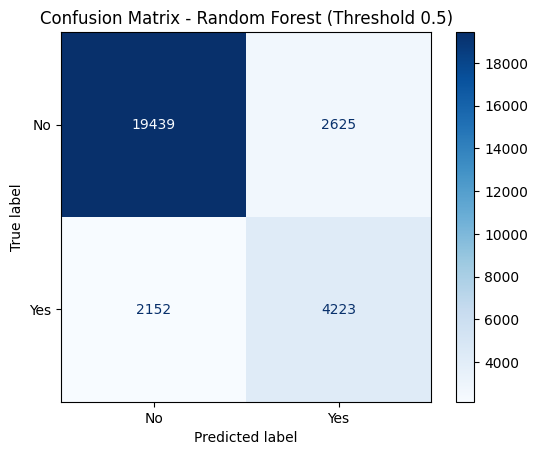

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_auc_score
)
import matplotlib.pyplot as plt

y_pred = rf_model.predict(X_test_final)
y_pred_proba = rf_model.predict_proba(X_test_final)[:, 1]

print("=== Evaluasi Model Random Forest (Threshold default 0.5) ===\n")
print(f"Accuracy  : {accuracy_score(y_test_enc, y_pred):.4f}")
print(f"Precision : {precision_score(y_test_enc, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test_enc, y_pred):.4f}")
print(f"F1-score  : {f1_score(y_test_enc, y_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test_enc, y_pred_proba):.4f}")

print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred, target_names=['No', 'Yes']))

cm = confusion_matrix(y_test_enc, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Random Forest (Threshold 0.5)')
plt.show()

Calculated scale_pos_weight: 3.46


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:08:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== Evaluasi Model XGBoost (RainTomorrow) ===

Accuracy  : 0.8041
Precision : 0.5456
Recall    : 0.7544
F1-score  : 0.6332
ROC-AUC   : 0.8716

Classification Report:
              precision    recall  f1-score   support

          No       0.92      0.82      0.87     22064
         Yes       0.55      0.75      0.63      6375

    accuracy                           0.80     28439
   macro avg       0.73      0.79      0.75     28439
weighted avg       0.84      0.80      0.81     28439



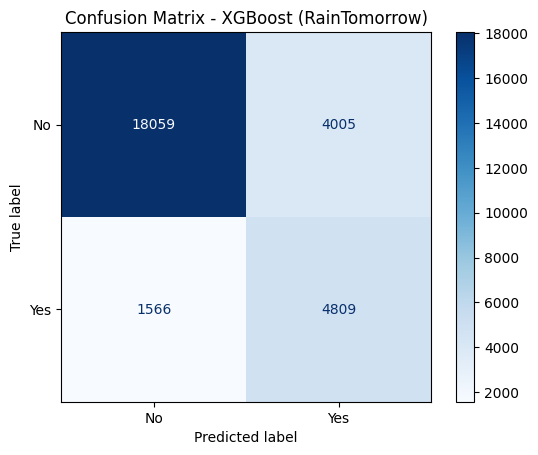

In [ ]:
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_auc_score
)
import matplotlib.pyplot as plt

count_no = (y_train_enc == 0).sum()
count_yes = (y_train_enc == 1).sum()

scale_pos_weight = count_no / count_yes
print(f"Calculated scale_pos_weight: {scale_pos_weight:.2f}")

X_train_xgb = X_train_encoded[selected_features]
X_test_xgb = X_test_encoded[selected_features]

xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight
)

xgb_model.fit(X_train_xgb, y_train_enc)
y_pred_xgb = xgb_model.predict(X_test_xgb)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]

print("\n=== Evaluasi Model XGBoost (RainTomorrow) ===\n")
print(f"Accuracy  : {accuracy_score(y_test_enc, y_pred_xgb):.4f}")
print(f"Precision : {precision_score(y_test_enc, y_pred_xgb):.4f}")
print(f"Recall    : {recall_score(y_test_enc, y_pred_xgb):.4f}")
print(f"F1-score  : {f1_score(y_test_enc, y_pred_xgb):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test_enc, y_pred_proba_xgb):.4f}")

print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_xgb, target_names=['No', 'Yes']))
cm_xgb = confusion_matrix(y_test_enc, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['No', 'Yes'])
disp_xgb.plot(cmap='Blues')
plt.title('Confusion Matrix - XGBoost (RainTomorrow)')
plt.show()

Shape X_train_lr: (113754, 13)
Shape X_test_lr : (28439, 13)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(



=== Evaluasi Model Logistic Regression (RainTomorrow) ===

Accuracy  : 0.7732
Precision : 0.4961
Recall    : 0.7611
F1-score  : 0.6007
ROC-AUC   : 0.8483

Classification Report:
              precision    recall  f1-score   support

          No       0.92      0.78      0.84     22064
         Yes       0.50      0.76      0.60      6375

    accuracy                           0.77     28439
   macro avg       0.71      0.77      0.72     28439
weighted avg       0.82      0.77      0.79     28439



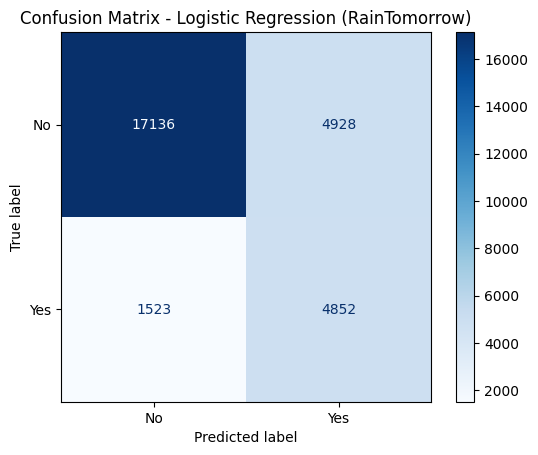

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_auc_score
)
import matplotlib.pyplot as plt

X_train_lr = X_train_encoded[selected_features]
X_test_lr = X_test_encoded[selected_features]

print(f"Shape X_train_lr: {X_train_lr.shape}")
print(f"Shape X_test_lr : {X_test_lr.shape}")

lr_model = LogisticRegression(
    random_state=42,
    class_weight='balanced',
    solver='liblinear',
    max_iter=1000,
    n_jobs=-1
)

lr_model.fit(X_train_lr, y_train_enc)
y_pred_lr = lr_model.predict(X_test_lr)
y_pred_proba_lr = lr_model.predict_proba(X_test_lr)[:, 1]

print("\n=== Evaluasi Model Logistic Regression (RainTomorrow) ===\n")
print(f"Accuracy  : {accuracy_score(y_test_enc, y_pred_lr):.4f}")
print(f"Precision : {precision_score(y_test_enc, y_pred_lr):.4f}")
print(f"Recall    : {recall_score(y_test_enc, y_pred_lr):.4f}")
print(f"F1-score  : {f1_score(y_test_enc, y_pred_lr):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test_enc, y_pred_proba_lr):.4f}")

print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_lr, target_names=['No', 'Yes']))

cm_lr = confusion_matrix(y_test_enc, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['No', 'Yes'])
disp_lr.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression (RainTomorrow)')
plt.show()

In [ ]:
import joblib
joblib.dump(rf_model, 'rf_rain_model.pkl')